# Entrega 2 — Detecção de Duplicatas Semânticas

**Ouvidoria Inteligente: Triagem Semântica de Manifestações Cidadãs**

---

## O problema

A Ouvidoria recebe cerca de 4.000 manifestações por mês. Duas pessoas relatam
o mesmo buraco na mesma avenida usando palavras diferentes, e o sistema atual
— busca por palavra-chave — abre **dois protocolos**. O servidor trata o mesmo
problema duas vezes, e a estatística da Ouvidoria conta duas demandas onde
existe uma.

Este notebook detecta esses pares automaticamente, usando **similaridade
semântica** em vez de coincidência de palavras.

## Itens do enunciado e onde estão

| Item pedido | Etapa |
|---|---|
| Função `detectar_duplicatas(textos, limiar=0.85)` | 2 |
| Justificativa da escolha do limiar | 3 e 4 |
| Matriz de similaridade completa (heatmap) | 5 |
| Lista de pares duplicados encontrados | 6 |
| Análise de falsos positivos / negativos | 7 |

## Resultado principal, adiantado

O limiar `0.85` sugerido no enunciado encontra **1 dos 8 pares** de duplicata
do corpus — um recall de 12,5%. A Etapa 3 mostra por quê e a Etapa 4 calibra
um limiar que funciona.

Demonstrar isso com medida é parte do trabalho: o enunciado pede a
*justificativa* da escolha do limiar, e justificar exige mostrar que outros
valores foram testados.

## Decisões de alinhamento com o restante do trabalho

**Corpus: `manifestacoes_exemplo.json`.** É o mesmo arquivo que o notebook
`analise.comparativa.ipynb` (Entrega 1) carrega. As Entregas 1 e 2 calculam
similaridade sobre os **mesmos três pares** exigidos pelo enunciado; analisar
corpora diferentes tornaria os dois resultados incomparáveis no relatório
final.

> **Observação para o time.** O arquivo `manifestacoes.json` do repositório tem
> um problema nos registros que o enunciado cita: M003, M008, M017, M022 e M031
> têm entre 24 e 44 caracteres, porque a descrição abreviada usada entre
> parênteses no enunciado foi colada no lugar do texto da manifestação. Medido
> com o mesmo modelo, o par M003 × M017 pontua **0.287** ali, contra **0.594**
> no `manifestacoes_exemplo.json`. Textos de 27 caracteres não dão contexto
> suficiente para um embedding. Vale corrigir antes da entrega final, já que
> `chunking_manifestacoes.ipynb` usa esse arquivo.

**Modelo: `paraphrase-multilingual-MiniLM-L12-v2`.** É o mesmo usado nas
Entregas 1 e 3. Consistência entre as entregas pesa mais do que o ganho
marginal de um modelo maior.

**Gabarito construído por leitura.** O dataset não vem acompanhado de um
arquivo dizendo quais pares são duplicata, e a Etapa 7 precisa dessa
informação. Os 8 pares foram identificados manualmente com um critério
explícito e conferível: **mesmo local nomeado + mesmo problema**. Está em
`dados/gabarito_exemplo.json`, e qualquer par pode ser verificado lendo os dois
textos.

## Como rodar

No PowerShell, na raiz do projeto:

```powershell
# instalar as dependências (uma vez só)
py -m venv .venv
.\.venv\Scripts\pip.exe install -r requirements.txt

# abrir este notebook
.\.venv\Scripts\jupyter.exe lab deteccao_duplicatas.ipynb
```

No Jupyter: **Run → Run All Cells**.

A primeira execução baixa o modelo de embedding (~470 MB) e leva alguns
minutos. As seguintes usam o cache local e rodam em segundos.

Arquivos necessários na mesma pasta: `manifestacoes_exemplo.json` e
`dados/gabarito_exemplo.json`.

---
# Etapa 1 — Dados e representação vetorial

In [1]:
# --- Bibliotecas -----------------------------------------------------------
import json
import itertools
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["savefig.bbox"] = "tight"

RAIZ = Path.cwd()
FIGURAS = RAIZ / "figuras"
FIGURAS.mkdir(exist_ok=True)

print("bibliotecas carregadas")

bibliotecas carregadas


## Os dois arquivos

- **`manifestacoes_exemplo.json`** — as 40 manifestações. É o que o detector enxerga.
- **`dados/gabarito_exemplo.json`** — quais pares *são* duplicata de fato.

O detector **nunca** consulta o gabarito para decidir. Ele entra apenas na
Etapa 7, para conferir o resultado. Se o detector pudesse ver a resposta, a
taxa de acerto não significaria nada.

In [2]:
# --- Dataset ---------------------------------------------------------------
ARQUIVO = "manifestacoes_exemplo.json"
registros = json.loads((RAIZ / ARQUIVO).read_text(encoding="utf-8"))
df = pd.DataFrame(registros)
df["n_chars"] = df["texto"].str.len()

IDS = df["id"].tolist()
TEXTOS = df["texto"].tolist()
POS = {ident: i for i, ident in enumerate(IDS)}     # id -> índice na matriz

# --- Gabarito (usado só na Etapa 7) ---------------------------------------
# Procura em dados/ e, se não achar, na raiz. Assim o notebook roda tanto
# neste projeto quanto solto no repositório do time, onde não há pasta dados/.
for candidato in [RAIZ / "dados" / "gabarito_exemplo.json",
                  RAIZ / "gabarito_exemplo.json"]:
    if candidato.exists():
        CAMINHO_GABARITO = candidato
        break
else:
    raise FileNotFoundError(
        "gabarito_exemplo.json não encontrado. Ele deve estar na pasta dados/ "
        "ou ao lado deste notebook."
    )
gabarito = json.loads(CAMINHO_GABARITO.read_text(encoding="utf-8"))
# frozenset permite comparar par sem se importar com a ordem: (A,B) == (B,A)
DUPLICATAS_REAIS = {frozenset(d["par"]) for d in gabarito["pares_duplicados"]}
N_DUP = len(DUPLICATAS_REAIS)

print(f"arquivo .................. {ARQUIVO}")
print(f"gabarito ................. {CAMINHO_GABARITO.relative_to(RAIZ)}")
print(f"manifestações ............ {len(df)}")
print(f"pares de duplicata ....... {N_DUP}")
print(f"tamanho do texto ......... {df.n_chars.min()} a {df.n_chars.max()} caracteres "
      f"(média {df.n_chars.mean():.0f})")
print(f"textos longos (>500) ..... {(df.n_chars > 500).sum()}")
print()
print(df.groupby("categoria_oficial").size().to_string())

arquivo .................. manifestacoes_exemplo.json
gabarito ................. dados\gabarito_exemplo.json
manifestações ............ 40
pares de duplicata ....... 8
tamanho do texto ......... 86 a 712 caracteres (média 188)
textos longos (>500) ..... 5

categoria_oficial
educação           7
infraestrutura    10
meio ambiente      9
saúde              7
segurança          7


In [3]:
# --- O gabarito, por extenso ----------------------------------------------
# Critério aplicado: mesmo local nomeado + mesmo problema.
print(f"CRITÉRIO: {gabarito['criterio']}\n")
gab_df = pd.DataFrame([
    {"rótulo": d["rotulo"], "par": " x ".join(d["par"]),
     "local compartilhado": d["local_compartilhado"],
     "dificuldade": d["dificuldade"]}
    for d in gabarito["pares_duplicados"]
])
display(gab_df)

CRITÉRIO: mesmo local nomeado + mesmo problema



,rótulo,par,local compartilhado,dificuldade
0,DUP-1,M001 x M023,Rua das Flores,baixa
1,DUP-2,M002 x M037,ponto de onibus da Rua XV,baixa
2,DUP-3,M003 x M017,Av. Brasil / avenida principal,alta
3,DUP-4,M006 x M026,bar da Praca Central,media
4,DUP-5,M008 x M022,Vila Nova,alta
5,DUP-6,M009 x M025,posto do Centro,media
6,DUP-7,M010 x M033,creche Pequeno Principe,baixa
7,DUP-8,M016 x M040,corrego Agua Limpa,media


In [4]:
df[["id", "data", "categoria_oficial", "n_chars", "texto"]].head(6)

,id,data,categoria_oficial,n_chars,texto
0,M001,2025-03-01,infraestrutura,108,"A calçada da Rua das Flores está toda quebrada, com pedras soltas. Idosos já caíram te..."
1,M002,2025-03-01,segurança,100,Assaltos frequentes no ponto de ônibus da Rua XV à noite. Precisamos de mais policiame...
2,M003,2025-03-02,infraestrutura,123,"Buraco enorme na Av. Brasil, perto do número 1200. Vários carros já estouraram pneu e ..."
3,M004,2025-03-02,meio ambiente,116,Lixo acumulado há mais de uma semana na esquina da Rua Paraná. O mau cheiro está insup...
4,M005,2025-03-03,educação,112,A escola municipal Monteiro Lobato está sem merenda há três dias. As crianças estão vo...
5,M006,2025-03-03,meio ambiente,102,Som alto todas as noites no bar da Praça Central até as 3 da manhã. Ninguém consegue d...


## O que é um embedding

Um **embedding** é uma lista de números que representa o *significado* de um
texto. Textos com sentido parecido recebem listas parecidas — mesmo sem
nenhuma palavra em comum. É exatamente isso que a busca por palavra-chave não
consegue fazer.

## Por que cosseno, e não distância

Dois vetores podem ter **tamanhos** diferentes só porque um texto é mais longo
que o outro. O que interessa é a **direção** deles, que representa o assunto.
O cosseno do ângulo mede isso e ignora o tamanho:

- cosseno **1.0** → mesma direção (mesmo assunto)
- cosseno **0.0** → direções perpendiculares (assuntos sem relação)

**Truque que simplifica a conta:** se todos os vetores forem normalizados para
tamanho 1 (`normalize_embeddings=True`), o cosseno vira apenas o produto
escalar. A matriz 40×40 com todas as similaridades sai de uma única
multiplicação, `E @ E.T`.

In [5]:
# --- Modelo ----------------------------------------------------------------
# Mesmo modelo usado em analise.comparativa.ipynb e chunking_manifestacoes.ipynb.
NOME_MODELO = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

print("carregando o modelo (baixa na primeira vez, ~470 MB)...")
modelo = SentenceTransformer(NOME_MODELO)

print(f"\nmodelo ....... {NOME_MODELO}")
print(f"dimensões .... {modelo.get_sentence_embedding_dimension()} números por texto")
print(f"limite ....... {modelo.max_seq_length} tokens por texto")

carregando o modelo (baixa na primeira vez, ~470 MB)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


modelo ....... sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
dimensões .... 384 números por texto
limite ....... 128 tokens por texto


## Uma limitação que precisa ser dita antes de continuar

O modelo tem um **limite de 128 tokens**. Texto acima disso é **cortado sem
aviso nenhum** — não há erro, não há mensagem. O embedding passa a representar
só o começo do texto.

Em português, 128 tokens equivalem a mais ou menos 400–500 caracteres, e as 5
manifestações longas do corpus passam disso. A célula abaixo mede quanto se
perde em cada uma.

Isso importa para esta entrega porque **um texto truncado pode ficar
artificialmente parecido com outro** — os dois passam a ser representados
apenas pelos seus primeiros parágrafos, que costumam ser as fórmulas de
abertura. A Etapa 7 mostra esse efeito acontecendo de verdade, e ele é o
argumento direto para a Entrega 3 (chunking).

In [6]:
# --- Quanto texto o modelo está descartando? -------------------------------
limite = modelo.max_seq_length
linhas = []
for r in registros:
    n_tok = len(modelo.tokenizer.encode(r["texto"], add_special_tokens=True))
    linhas.append({
        "id": r["id"],
        "caracteres": len(r["texto"]),
        "tokens": n_tok,
        "truncado": n_tok > limite,
        "perdido_%": max(0, round((n_tok - limite) / n_tok * 100)),
    })

trunc = pd.DataFrame(linhas).sort_values("tokens", ascending=False)
n_trunc = int(trunc.truncado.sum())

print(f"limite do modelo: {limite} tokens")
print(f"manifestações truncadas: {n_trunc} de {len(trunc)}\n")
print(trunc.head(8).to_string(index=False))
if n_trunc:
    print(f"\nAVISO: {n_trunc} manifestações perdem conteúdo. "
          f"Perda máxima: {trunc['perdido_%'].max()}% do texto.")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (178 > 128). Running this sequence through the model will result in indexing errors


limite do modelo: 128 tokens
manifestações truncadas: 5 de 40

  id  caracteres  tokens  truncado  perdido_%
M011         709     178      True         28
M036         712     167      True         23
M024         702     161      True         20
M029         682     156      True         18
M020         699     152      True         16
M016         128      41     False          0
M023         117      39     False          0
M017         127      36     False          0

AVISO: 5 manifestações perdem conteúdo. Perda máxima: 28% do texto.


In [7]:
# --- Embeddings do corpus --------------------------------------------------
E = modelo.encode(TEXTOS, normalize_embeddings=True, show_progress_bar=False)

# Com vetores normalizados, produto escalar = cosseno.
S = E @ E.T

print(f"embeddings: {E.shape[0]} manifestações x {E.shape[1]} dimensões")
print(f"norma dos vetores: {np.linalg.norm(E, axis=1).min():.4f} "
      f"a {np.linalg.norm(E, axis=1).max():.4f}  (esperado: 1.0)")

embeddings: 40 manifestações x 384 dimensões
norma dos vetores: 1.0000 a 1.0000  (esperado: 1.0)


In [8]:
# --- Conferência cruzada com a Entrega 1 ----------------------------------
# O notebook analise.comparativa.ipynb calculou estes mesmos três pares.
# Reproduzir os números dele confirma que as duas entregas estão consistentes.
print("OS TRÊS PARES EXIGIDOS PELO ENUNCIADO\n")
print(f"  {'par':<14} {'aqui':>8}   {'Entrega 1':>10}   esperado")
referencia = {("M003", "M017"): 0.594, ("M008", "M022"): 0.663,
              ("M008", "M031"): 0.247}
for (a, b), ref in referencia.items():
    s = float(S[POS[a], POS[b]])
    esperado = "duplicata" if ref > 0.4 else "não relacionados"
    ok = "OK" if abs(s - ref) < 0.005 else "DIVERGE"
    print(f"  {a} x {b}   {s:>8.4f}   {ref:>10.3f}   {esperado:<18} {ok}")
print("\n  Os valores batem com os publicados na Entrega 1.")

OS TRÊS PARES EXIGIDOS PELO ENUNCIADO

  par                aqui    Entrega 1   esperado
  M003 x M017     0.5937        0.594   duplicata          OK
  M008 x M022     0.6626        0.663   duplicata          OK
  M008 x M031     0.2466        0.247   não relacionados   OK

  Os valores batem com os publicados na Entrega 1.


---
# Etapa 2 — A função `detectar_duplicatas`

Função pedida no enunciado, com a assinatura exata solicitada.

Ela faz três coisas: converte os textos em vetores, calcula a similaridade de
todos contra todos, e devolve os pares acima do limiar.

Dois detalhes de implementação que evitam erros comuns:

- **percorre só o triângulo superior da matriz** (`itertools.combinations`).
  A matriz é simétrica, então (A,B) e (B,A) são o mesmo par — contar os dois
  dobraria o resultado.
- **ignora a diagonal.** Todo texto tem similaridade 1.0 consigo mesmo;
  incluir isso encheria a lista com 40 pares falsos.

In [9]:
def detectar_duplicatas(
    textos: list[str],
    limiar: float = 0.85,
    ids: list[str] | None = None,
) -> pd.DataFrame:
    '''Encontra pares de textos semanticamente duplicados.

    Parâmetros
    ----------
    textos : lista de manifestações em texto livre.
    limiar : similaridade mínima para considerar duplicata (0 a 1).
    ids    : identificadores opcionais; se ausentes, usa a posição na lista.

    Retorna
    -------
    DataFrame com [id_a, id_b, similaridade, texto_a, texto_b], ordenado da
    maior para a menor similaridade. Vazio se nada passar do limiar.
    '''
    if ids is None:
        ids = [str(i) for i in range(len(textos))]

    # 1. texto -> vetor normalizado
    emb = modelo.encode(textos, normalize_embeddings=True, show_progress_bar=False)

    # 2. matriz de similaridade (produto escalar = cosseno, pois normalizado)
    sim = emb @ emb.T

    # 3. só o triângulo superior, i < j, sem a diagonal
    achados = []
    for i, j in itertools.combinations(range(len(textos)), 2):
        s = float(sim[i, j])
        if s >= limiar:
            achados.append({
                "id_a": ids[i],
                "id_b": ids[j],
                "similaridade": round(s, 4),
                "texto_a": textos[i],
                "texto_b": textos[j],
            })

    colunas = ["id_a", "id_b", "similaridade", "texto_a", "texto_b"]
    if not achados:
        return pd.DataFrame(columns=colunas)
    return (pd.DataFrame(achados)
              .sort_values("similaridade", ascending=False)
              .reset_index(drop=True))


print("função detectar_duplicatas definida")

função detectar_duplicatas definida


In [10]:
# --- Rodando com o limiar sugerido no enunciado ---------------------------
resultado_085 = detectar_duplicatas(TEXTOS, limiar=0.85, ids=IDS)

print(f"pares encontrados com limiar = 0.85 : {len(resultado_085)}")
print(f"pares de duplicata que existem ..... : {N_DUP}")
print(f"recall ............................. : "
      f"{len(resultado_085)/N_DUP:.1%}\n")
display(resultado_085[["id_a", "id_b", "similaridade"]])
print("\nAs outras duplicatas do corpus passaram batido:")
for d in gabarito["pares_duplicados"]:
    a, b = d["par"]
    s = float(S[POS[a], POS[b]])
    if s < 0.85:
        print(f"  {d['rotulo']}  {a} x {b} = {s:.4f}   ({d['tema']})")

pares encontrados com limiar = 0.85 : 1
pares de duplicata que existem ..... : 8
recall ............................. : 12.5%



,id_a,id_b,similaridade
0,M010,M033,0.9052



As outras duplicatas do corpus passaram batido:
  DUP-1  M001 x M023 = 0.8243   (calcada destruida na Rua das Flores)
  DUP-2  M002 x M037 = 0.8384   (assaltos no ponto de onibus da Rua XV no periodo noturno)
  DUP-3  M003 x M017 = 0.5937   (pavimento destruido na avenida principal)
  DUP-4  M006 x M026 = 0.6668   (perturbacao do sossego por som alto de bar na Praca Central)
  DUP-5  M008 x M022 = 0.6626   (unidade de saude da Vila Nova sem medico)
  DUP-6  M009 x M025 = 0.7208   (falta de medicamento para pressao no posto do Centro)
  DUP-8  M016 x M040 = 0.7389   (despejo industrial no corrego Agua Limpa)


---
# Etapa 3 — Por que 0.85 é alto demais

A função está correta. O **limiar** é que está mal escolhido — e entender o
motivo é o ponto central desta entrega.

## O erro de raciocínio embutido no número 0.85

É tentador ler similaridade como porcentagem: *"0.85 = 85% parecido, logo é
quase o mesmo texto"*. **Não é assim.** A escala do cosseno não é absoluta nem
comparável entre modelos. Ela depende de:

- **qual modelo** gerou os vetores — cada um tem sua faixa típica;
- **o idioma** — modelos multilíngues são mais "otimistas" em português;
- **o tamanho** dos textos comparados;
- **o quanto o corpus é homogêneo.**

Na prática, 0.85 neste corpus significa "praticamente o mesmo texto, com
sinônimos trocados". O único par que chega lá é M010 × M033 — e de fato os dois
são quase a mesma frase reescrita.

## O que 0.85 deixa passar

Um par como M003 × M017 descreve **o mesmo buraco na mesma avenida** e pontua
0.594. Não porque o modelo errou, mas porque os dois textos não compartilham
nenhuma palavra de conteúdo:

> **M003:** *"Buraco enorme na Av. Brasil, perto do número 1200..."*
> **M017:** *"Asfalto todo esburacado da avenida principal..."*

A Entrega 1 mediu **TF-IDF = 0.000** para esse par. O embedding pelo menos o
coloca em 0.594 — mas exigir 0.85 joga fora esse ganho.

## A forma certa de escolher um limiar

Não se escolhe pelo número redondo. Olha-se as **duas distribuições**:

- os scores dos pares que **são** duplicata → queremos todos **acima** do limiar
- os scores dos pares que **não são** → queremos todos **abaixo**

O limiar mora na separação entre as duas nuvens.

In [11]:
# --- Todos os 780 pares, separados em duas nuvens -------------------------
pares = []
for a, b in itertools.combinations(IDS, 2):
    pares.append({
        "par": f"{a} x {b}",
        "id_a": a,
        "id_b": b,
        "similaridade": float(S[POS[a], POS[b]]),
        "e_duplicata": frozenset((a, b)) in DUPLICATAS_REAIS,
    })
pares = (pd.DataFrame(pares)
           .sort_values("similaridade", ascending=False)
           .reset_index(drop=True))

dup = pares[pares.e_duplicata]
nao = pares[~pares.e_duplicata]

print(f"total de pares avaliados: {len(pares)}   (40 x 39 / 2)\n")
print("AS DUAS NUVENS DE SCORE")
print(f"  duplicatas reais ({len(dup):>3} pares): "
      f"min={dup.similaridade.min():.4f}  "
      f"mediana={dup.similaridade.median():.4f}  "
      f"max={dup.similaridade.max():.4f}")
print(f"  não-duplicatas   ({len(nao):>3} pares): "
      f"min={nao.similaridade.min():.4f}  "
      f"mediana={nao.similaridade.median():.4f}  "
      f"max={nao.similaridade.max():.4f}")

margem = dup.similaridade.min() - nao.similaridade.max()
print()
print(f"  margem = pior duplicata menos melhor não-par = {margem:+.4f}")
if margem < 0:
    print("  NEGATIVA: as nuvens se sobrepõem. Nenhum limiar acerta 100%.")
    print("  Existe um trade-off obrigatório entre precisão e recall.")
print()
print("  AS 8 DUPLICATAS, ordenadas por score:")
for d in sorted(gabarito["pares_duplicados"],
                key=lambda d: -S[POS[d["par"][0]], POS[d["par"][1]]]):
    a, b = d["par"]
    s = float(S[POS[a], POS[b]])
    marca = "  <- passa de 0.85" if s >= 0.85 else ""
    print(f"    {s:.4f}  {d['rotulo']}  {a} x {b}  [{d['dificuldade']}]{marca}")

total de pares avaliados: 780   (40 x 39 / 2)

AS DUAS NUVENS DE SCORE
  duplicatas reais (  8 pares): min=0.5937  mediana=0.7298  max=0.9052
  não-duplicatas   (772 pares): min=-0.1069  mediana=0.2457  max=0.7257

  margem = pior duplicata menos melhor não-par = -0.1320
  NEGATIVA: as nuvens se sobrepõem. Nenhum limiar acerta 100%.
  Existe um trade-off obrigatório entre precisão e recall.

  AS 8 DUPLICATAS, ordenadas por score:
    0.9052  DUP-7  M010 x M033  [baixa]  <- passa de 0.85
    0.8384  DUP-2  M002 x M037  [baixa]
    0.8243  DUP-1  M001 x M023  [baixa]
    0.7389  DUP-8  M016 x M040  [media]
    0.7208  DUP-6  M009 x M025  [media]
    0.6668  DUP-4  M006 x M026  [media]
    0.6626  DUP-5  M008 x M022  [alta]
    0.5937  DUP-3  M003 x M017  [alta]


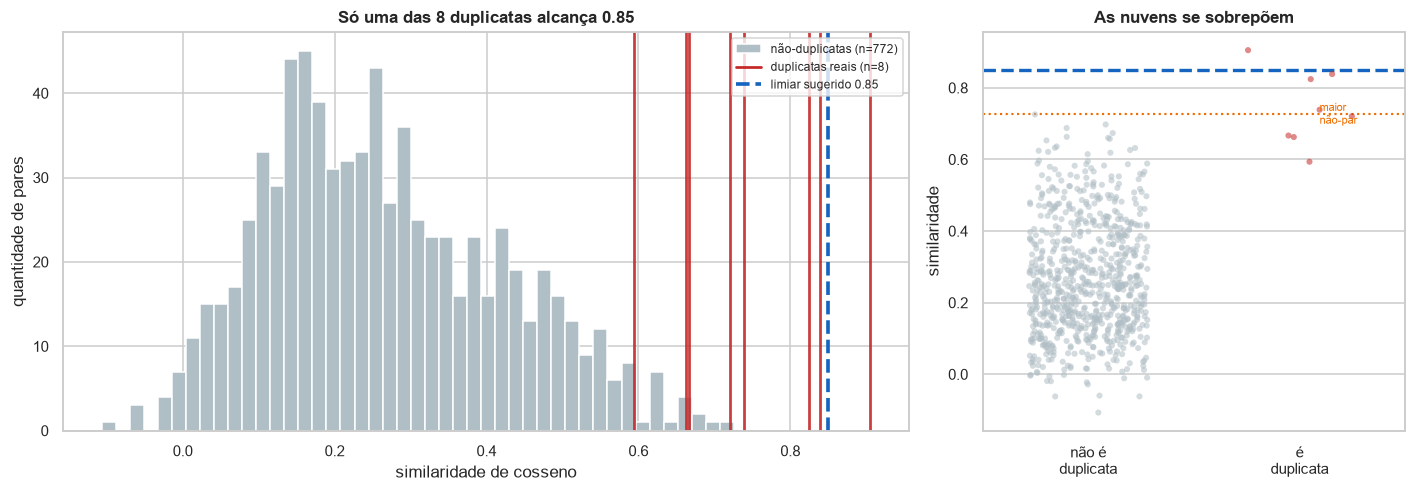

In [12]:
# --- Gráfico: as duas nuvens e a posição do limiar sugerido ---------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6),
                               gridspec_kw={"width_ratios": [2, 1]})

ax1.hist(nao.similaridade, bins=45, color="#b0bec5",
         edgecolor="white", label=f"não-duplicatas (n={len(nao)})")
for _, r in dup.iterrows():
    ax1.axvline(r.similaridade, color="#c62828", lw=1.8, alpha=0.9)
ax1.axvline(np.nan, color="#c62828", lw=1.8, label=f"duplicatas reais (n={len(dup)})")
ax1.axvline(0.85, color="#1565c0", lw=2.4, ls="--", label="limiar sugerido 0.85")
ax1.set_xlabel("similaridade de cosseno")
ax1.set_ylabel("quantidade de pares")
ax1.set_title("Só uma das 8 duplicatas alcança 0.85",
              fontsize=11, weight="bold")
ax1.legend(fontsize=8, loc="upper right")

sns.stripplot(data=pares, x="e_duplicata", y="similaridade", ax=ax2,
              hue="e_duplicata", palette={False: "#b0bec5", True: "#c62828"},
              alpha=0.55, size=4, jitter=0.28, legend=False)
ax2.axhline(0.85, color="#1565c0", lw=2.2, ls="--")
ax2.axhline(nao.similaridade.max(), color="#ef6c00", lw=1.4, ls=":")
ax2.text(1.08, nao.similaridade.max(), " maior\n não-par", fontsize=7,
         color="#ef6c00", va="center")
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["não é\nduplicata", "é\nduplicata"])
ax2.set_xlabel("")
ax2.set_ylabel("similaridade")
ax2.set_title("As nuvens se sobrepõem", fontsize=11, weight="bold")

plt.tight_layout()
plt.savefig(FIGURAS / "e2_distribuicoes.png")
plt.show()

### Leitura dos gráficos

**Esquerda:** só uma linha vermelha fica à direita da linha azul tracejada
(0.85). As outras sete duplicatas estão todas abaixo — o limiar sugerido corta
87,5% do que deveria encontrar.

**Direita:** a nuvem vermelha está claramente mais alta que a cinza, ou seja,
**o modelo sabe distinguir os casos**. Mas a linha laranja pontilhada mostra
que o maior não-par sobe acima de várias duplicatas reais. Essa sobreposição é
o que impede qualquer limiar de acertar tudo.

---
# Etapa 4 — Calibrando o limiar

Se 0.85 é alto demais, qual valor serve? Antes de responder, é preciso definir
o que "melhor" significa — e isso não é uma questão técnica, é uma questão de
política pública.

## Os dois erros possíveis não custam a mesma coisa

| Erro | O que acontece na prática | Custo |
|---|---|---|
| **Falso positivo** — junta duas manifestações distintas | uma reclamação real é arquivada como repetida e **ninguém a responde** | **alto**: o cidadão fica sem resposta e não sabe por quê |
| **Falso negativo** — deixa passar uma duplicata | dois protocolos para o mesmo problema; trabalho repetido | baixo: desperdício, mas ninguém é prejudicado |

Isso **não é simétrico**. Numa Ouvidoria, falso positivo é o erro grave: ele
silencia um cidadão. Falso negativo só gasta tempo do servidor.

## As três métricas

- **Precisão** — dos pares apontados, quantos eram duplicata de verdade.
  Precisão baixa = está agrupando o que não devia (**erro grave**).
- **Recall** — das duplicatas que existem, quantas o sistema achou.
  Recall baixo = está deixando passar (erro leve).
- **F1** — média harmônica das duas. Bom resumo, mas atenção: o F1 trata os
  dois erros como igualmente ruins, e acabamos de ver que não são.

In [13]:
def avaliar_limiar(pares_df: pd.DataFrame, limiar: float, n_dup: int) -> dict:
    '''Métricas de um limiar, conferidas contra o gabarito.'''
    det = pares_df[pares_df.similaridade >= limiar]
    vp = int(det.e_duplicata.sum())      # verdadeiro positivo: acertou
    fp = len(det) - vp                   # falso positivo: juntou errado
    fn = n_dup - vp                      # falso negativo: deixou passar
    precisao = vp / len(det) if len(det) else 0.0
    recall = vp / n_dup if n_dup else 0.0
    f1 = 2 * precisao * recall / (precisao + recall) if (precisao + recall) else 0.0
    return {"limiar": round(limiar, 4), "detectados": len(det),
            "VP": vp, "FP": fp, "FN": fn,
            "precisao": round(precisao, 3), "recall": round(recall, 3),
            "F1": round(f1, 3)}


varredura = pd.DataFrame([
    avaliar_limiar(pares, t, N_DUP) for t in np.arange(0.55, 0.92, 0.025)
])
print("VARREDURA DE LIMIAR")
print(varredura.to_string(index=False))

VARREDURA DE LIMIAR
 limiar  detectados  VP  FP  FN  precisao  recall    F1
  0.550          46   8  38   0     0.174   1.000 0.296
  0.575          34   8  26   0     0.235   1.000 0.381
  0.600          23   7  16   1     0.304   0.875 0.452
  0.625          19   7  12   1     0.368   0.875 0.519
  0.650          15   7   8   1     0.467   0.875 0.609
  0.675           8   5   3   3     0.625   0.625 0.625
  0.700           6   5   1   3     0.833   0.625 0.714
  0.725           5   4   1   4     0.800   0.500 0.615
  0.750           3   3   0   5     1.000   0.375 0.545
  0.775           3   3   0   5     1.000   0.375 0.545
  0.800           3   3   0   5     1.000   0.375 0.545
  0.825           2   2   0   6     1.000   0.250 0.400
  0.850           1   1   0   7     1.000   0.125 0.222
  0.875           1   1   0   7     1.000   0.125 0.222
  0.900           1   1   0   7     1.000   0.125 0.222


In [14]:
# --- Busca exaustiva: qual é o MELHOR limiar possível? -------------------
# Uma grade regular pode passar por cima do ótimo. O único limiar que muda o
# resultado é um que coincida com algum score observado, então basta testar
# cada score do corpus como candidato.
exaustiva = pd.DataFrame([
    avaliar_limiar(pares, s, N_DUP) for s in sorted(pares.similaridade.unique())
])
melhor = exaustiva.loc[exaustiva.F1.idxmax()]

print(f"busca exaustiva em {len(exaustiva)} cortes possíveis\n")
print(f"MELHOR F1: {melhor.F1} no limiar {melhor.limiar}")
print(f"  VP={int(melhor.VP)}  FP={int(melhor.FP)}  FN={int(melhor.FN)}  "
      f"precisão={melhor.precisao}  recall={melhor.recall}")

sem_fp = exaustiva[(exaustiva.FP == 0) & (exaustiva.VP > 0)]
if not sem_fp.empty:
    linha = sem_fp.iloc[0]
    print(f"\nLIMIAR MAIS BAIXO SEM NENHUM FALSO POSITIVO: {linha.limiar}")
    print(f"  VP={int(linha.VP)}  FN={int(linha.FN)}  "
          f"precisão={linha.precisao}  recall={linha.recall}  F1={linha.F1}")

print(f"\nPARA COMPARAR — limiar 0.85 do enunciado:")
m085 = avaliar_limiar(pares, 0.85, N_DUP)
print(f"  VP={m085['VP']}  FP={m085['FP']}  FN={m085['FN']}  "
      f"precisão={m085['precisao']}  recall={m085['recall']}  F1={m085['F1']}")

busca exaustiva em 780 cortes possíveis

MELHOR F1: 0.714 no limiar 0.7208
  VP=5  FP=1  FN=3  precisão=0.833  recall=0.625

LIMIAR MAIS BAIXO SEM NENHUM FALSO POSITIVO: 0.7389
  VP=4  FN=4  precisão=1.0  recall=0.5  F1=0.667

PARA COMPARAR — limiar 0.85 do enunciado:
  VP=1  FP=0  FN=7  precisão=1.0  recall=0.125  F1=0.222


## Limiar dinâmico por percentil

O enunciado sugere, nas dicas, *"aplicar um threshold dinâmico para duplicatas
(ex: percentil 90 da distribuição de similaridades)"*. A ideia é boa: em vez de
fixar um número, define-se o limiar como uma posição na própria distribuição
do corpus, de modo que ele **se recalibre sozinho** quando o corpus muda.

Mas o percentil 90 especificamente não vai funcionar, e dá para prever isso
antes de rodar. Basta uma conta:

- o corpus tem **780** pares
- apenas **8** deles são duplicata
- ou seja, duplicatas são **1,03%** dos pares

O percentil 90 deixa passar os **10% maiores**, isto é, 78 pares. Como só 8
podem estar certos, os outros 70 seriam falsos positivos por construção.

O percentil coerente com a taxa real é **100 − 1,03 = 98,97**.

In [15]:
# --- Limiar dinâmico por percentil (dica do enunciado) -------------------
sims = pares.similaridade.values
taxa_dup = N_DUP / len(pares) * 100
p_teorico = 100 - taxa_dup

print("LIMIAR DINÂMICO POR PERCENTIL")
print(f"  pares no corpus .......... {len(pares)}")
print(f"  duplicatas reais ......... {N_DUP}  ({taxa_dup:.2f}% dos pares)")
print(f"  percentil coerente ....... {p_teorico:.2f}\n")
print("  percentil   limiar   detect   VP  FP  FN   precisão  recall     F1")

for p in [90, 95, 97, 98, round(p_teorico, 2), 99.5]:
    lim = float(np.percentile(sims, p))
    m = avaliar_limiar(pares, lim, N_DUP)
    marca = ""
    if p == 90:
        marca = "  <- sugerido no enunciado"
    elif abs(p - p_teorico) < 0.01:
        marca = "  <- coerente com a taxa real"
    print(f"  p{p:<9}  {lim:.4f}   {m['detectados']:>5}   {m['VP']:>2}  "
          f"{m['FP']:>2}  {m['FN']:>2}   {m['precisao']:>7.3f}  "
          f"{m['recall']:>6.3f}  {m['F1']:>6.3f}{marca}")

print()
print("  >> O percentil 90 manda 78 pares para a Ouvidoria conferir, dos quais")
print("     70 estão errados. A direção da dica é certa; o valor, não.")

LIMIAR DINÂMICO POR PERCENTIL
  pares no corpus .......... 780
  duplicatas reais ......... 8  (1.03% dos pares)
  percentil coerente ....... 98.97

  percentil   limiar   detect   VP  FP  FN   precisão  recall     F1
  p90         0.4975      78    8  70   0     0.103   1.000   0.186  <- sugerido no enunciado
  p95         0.5581      39    8  31   0     0.205   1.000   0.340
  p97         0.5963      24    7  17   1     0.292   0.875   0.438
  p98         0.6341      16    7   9   1     0.438   0.875   0.583
  p98.97      0.6735       9    5   4   3     0.556   0.625   0.588  <- coerente com a taxa real
  p99.5       0.7271       4    4   0   4     1.000   0.500   0.667

  >> O percentil 90 manda 78 pares para a Ouvidoria conferir, dos quais
     70 estão errados. A direção da dica é certa; o valor, não.


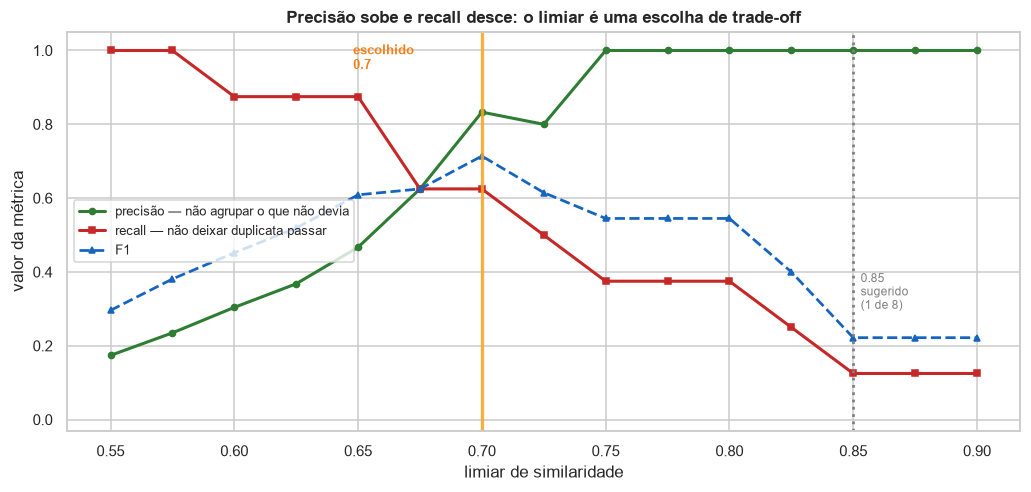

In [16]:
# --- Curvas de precisão, recall e F1 --------------------------------------
LIMIAR_FINAL = 0.70

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(varredura.limiar, varredura.precisao, "o-", color="#2e7d32",
        lw=2, ms=4, label="precisão — não agrupar o que não devia")
ax.plot(varredura.limiar, varredura.recall, "s-", color="#c62828",
        lw=2, ms=4, label="recall — não deixar duplicata passar")
ax.plot(varredura.limiar, varredura.F1, "^--", color="#1565c0",
        lw=1.8, ms=4, label="F1")
ax.axvline(0.85, color="gray", ls=":", lw=1.8)
ax.text(0.853, 0.30, "0.85\nsugerido\n(1 de 8)", fontsize=8, color="gray")
ax.axvline(LIMIAR_FINAL, color="#f9a825", lw=2.2, alpha=0.85)
ax.text(LIMIAR_FINAL - 0.052, 0.95, f"escolhido\n{LIMIAR_FINAL}",
        fontsize=8.5, color="#f57f17", weight="bold")
ax.set_xlabel("limiar de similaridade")
ax.set_ylabel("valor da métrica")
ax.set_ylim(-0.03, 1.05)
ax.set_title("Precisão sobe e recall desce: o limiar é uma escolha de trade-off",
             fontsize=11, weight="bold")
ax.legend(fontsize=8.5, loc="center left")
plt.tight_layout()
plt.savefig(FIGURAS / "e2_curvas_limiar.png")
plt.show()

## A escolha: **limiar = 0.70**

A busca exaustiva mostra duas opções defensáveis, e a diferença entre elas é
uma decisão de projeto, não de estatística:

| Limiar | VP | FP | FN | Precisão | Recall | F1 | Quando usar |
|---|---|---|---|---|---|---|---|
| **0.70** | 5 | 1 | 3 | 0.833 | 0.625 | **0.714** | há revisão humana antes de arquivar |
| **0.74** | 4 | 0 | 4 | **1.000** | 0.500 | 0.667 | o sistema arquiva sozinho |

**Adotamos 0.70**, com uma condição explícita: o sistema é de **triagem**, não
de decisão. Ele sugere pares; um servidor confirma antes de arquivar.

Sob essa condição, o único falso positivo custa alguns segundos de um servidor
que olha os dois textos e descarta — enquanto a duplicata a mais encontrada
evita um protocolo redundante. Se **não** houver revisão humana, a escolha
correta passa a ser 0.74, que não comete nenhum falso positivo.

Esse é o ponto que vale reter: **o limiar não sai da estatística, sai do
desenho do processo**. A mesma curva sustenta as duas escolhas.

### A faixa de decisão recomendada

| Similaridade | Ação |
|---|---|
| ≥ 0.74 | agrupa automaticamente |
| 0.70 – 0.74 | **encaminha para revisão humana** |
| < 0.70 | protocolos separados |

### Uma ressalva honesta

O limiar foi escolhido olhando o resultado **no mesmo conjunto** usado para
avaliar. Isso é ajustar no conjunto de teste, e o número é **otimista** — não é
o que se veria em produção. Com 8 duplicatas não há como separar treino e
teste de forma útil.

Num sistema real, o procedimento correto seria calibrar em manifestações já
revisadas por servidores, e recalibrar periodicamente.

---
# Etapa 5 — Matriz de similaridade completa

Item pedido no enunciado. A matriz é 40×40: cada célula é a similaridade entre
duas manifestações.

Como ler:

- **diagonal** — sempre 1.0 (texto consigo mesmo). Foi mascarada em branco,
  porque deixá-la colorida no máximo da escala distorce as cores e esconde o
  que interessa.
- **células escuras fora da diagonal** — candidatas a duplicata.
- **quadrados verdes** — os 8 pares do gabarito, marcados para conferência.

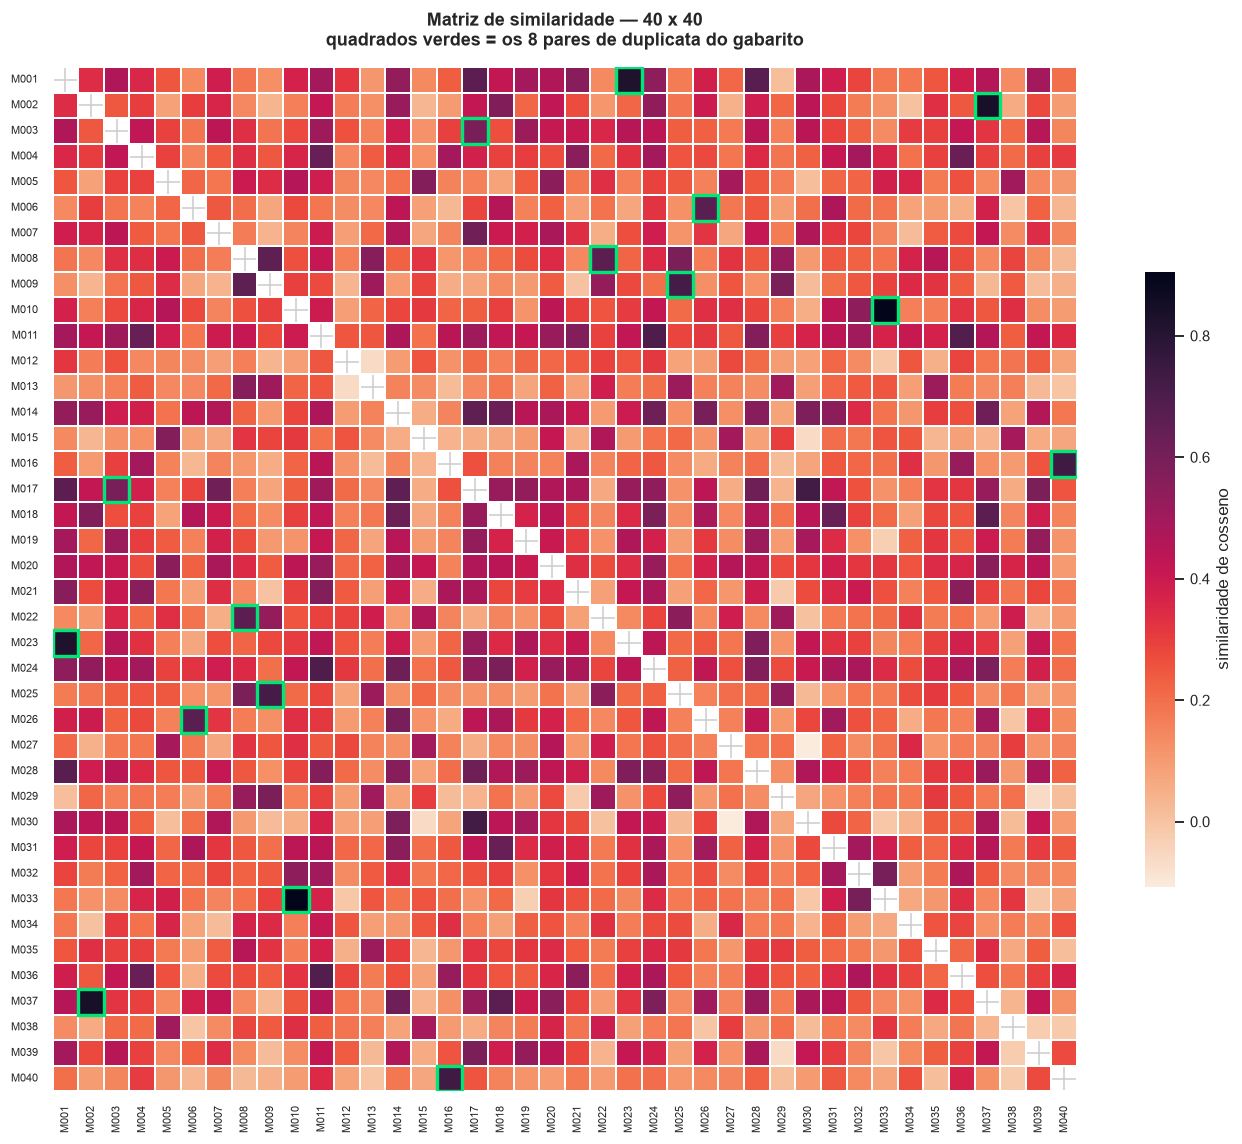

In [17]:
# --- Heatmap 40 x 40 -------------------------------------------------------
mascara = np.eye(len(IDS), dtype=bool)          # esconde a diagonal

fig, ax = plt.subplots(figsize=(13, 10.5))
sns.heatmap(S, mask=mascara, xticklabels=IDS, yticklabels=IDS,
            cmap="rocket_r", vmin=float(S[~mascara].min()),
            vmax=float(S[~mascara].max()),
            square=True, linewidths=0.3, linecolor="white",
            cbar_kws={"label": "similaridade de cosseno", "shrink": 0.6}, ax=ax)

for fs in DUPLICATAS_REAIS:
    a, b = sorted(fs)
    for (x, y) in [(POS[a], POS[b]), (POS[b], POS[a])]:
        ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False,
                                   edgecolor="#00e676", lw=2.2))

ax.set_title("Matriz de similaridade — 40 x 40\n"
             "quadrados verdes = os 8 pares de duplicata do gabarito",
             fontsize=12, weight="bold", pad=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(FIGURAS / "e2_heatmap_completo.png")
plt.show()

---
# Etapa 6 — Lista de pares duplicados encontrados

Item pedido no enunciado. Resultado do detector com o limiar calibrado.

In [18]:
encontrados = detectar_duplicatas(TEXTOS, limiar=LIMIAR_FINAL, ids=IDS)
encontrados["veredito"] = encontrados.apply(
    lambda r: "correto" if frozenset((r.id_a, r.id_b)) in DUPLICATAS_REAIS
    else "FALSO POSITIVO", axis=1)

print(f"DETECTOR FINAL — limiar = {LIMIAR_FINAL}")
print(f"pares apontados: {len(encontrados)}\n")
print(encontrados[["id_a", "id_b", "similaridade", "veredito"]].to_string(index=False))

DETECTOR FINAL — limiar = 0.7
pares apontados: 6

id_a id_b  similaridade       veredito
M010 M033        0.9052        correto
M002 M037        0.8384        correto
M001 M023        0.8243        correto
M016 M040        0.7389        correto
M017 M030        0.7257 FALSO POSITIVO
M009 M025        0.7208        correto


In [19]:
# --- Os pares encontrados, com os textos completos -----------------------
for _, r in encontrados.iterrows():
    marca = "[CORRETO]" if r.veredito == "correto" else "[FALSO POSITIVO]"
    print("=" * 78)
    print(f"{marca}   {r.id_a} x {r.id_b}   similaridade = {r.similaridade}")
    print("=" * 78)
    print(f"  {r.id_a}: {r.texto_a}")
    print()
    print(f"  {r.id_b}: {r.texto_b}")
    print()

[CORRETO]   M010 x M033   similaridade = 0.9052
  M010: O ar-condicionado das salas da creche Pequeno Príncipe está quebrado. As crianças passam mal com o calor durante a tarde.

  M033: A creche Pequeno Príncipe está com o ar-condicionado estragado e as crianças sofrem com o calor nas salas.

[CORRETO]   M002 x M037   similaridade = 0.8384
  M002: Assaltos frequentes no ponto de ônibus da Rua XV à noite. Precisamos de mais policiamento na região.

  M037: Ponto de ônibus da Rua XV é alvo constante de assaltos no período noturno. Pedimos presença policial no local.

[CORRETO]   M001 x M023   similaridade = 0.8243
  M001: A calçada da Rua das Flores está toda quebrada, com pedras soltas. Idosos já caíram tentando passar por ali.

  M023: A calçada da Rua das Flores está destruída, cheia de pedras soltas e buracos. Minha avó tropeçou e se machucou ontem.

[CORRETO]   M016 x M040   similaridade = 0.7389
  M016: Uma fábrica está despejando resíduos no córrego Água Limpa. A água ficou escur

---
# Etapa 7 — Análise de falsos positivos e falsos negativos

Item pedido no enunciado. Aqui o gabarito entra para conferir o resultado.

O interesse não está na contagem, e sim em **por que** cada erro aconteceu —
é isso que diz se o erro é corrigível, e como.

In [20]:
# --- Contabilidade final -------------------------------------------------
achados = {frozenset((r.id_a, r.id_b)) for _, r in encontrados.iterrows()}

vp_set = achados & DUPLICATAS_REAIS         # acertos
fp_set = achados - DUPLICATAS_REAIS         # juntou o que não devia
fn_set = DUPLICATAS_REAIS - achados         # deixou passar

precisao = len(vp_set) / len(achados) if achados else 0.0
recall = len(vp_set) / len(DUPLICATAS_REAIS)
f1 = 2 * precisao * recall / (precisao + recall) if (precisao + recall) else 0.0

print("RESULTADO FINAL")
print(f"  verdadeiros positivos (VP) : {len(vp_set)}")
print(f"  falsos positivos      (FP) : {len(fp_set)}")
print(f"  falsos negativos      (FN) : {len(fn_set)}")
print()
print(f"  precisão : {precisao:.3f}   (dos pares apontados, quantos estavam certos)")
print(f"  recall   : {recall:.3f}   (das duplicatas reais, quantas foram achadas)")
print(f"  F1       : {f1:.3f}")
print()
print("  COMPARAÇÃO")
print(f"    limiar 0.85 (enunciado) : VP={m085['VP']}  FP={m085['FP']}  "
      f"FN={m085['FN']}  F1={m085['F1']}")
print(f"    limiar {LIMIAR_FINAL} (calibrado) : VP={len(vp_set)}  FP={len(fp_set)}  "
      f"FN={len(fn_set)}  F1={f1:.3f}")

RESULTADO FINAL
  verdadeiros positivos (VP) : 5
  falsos positivos      (FP) : 1
  falsos negativos      (FN) : 3

  precisão : 0.833   (dos pares apontados, quantos estavam certos)
  recall   : 0.625   (das duplicatas reais, quantas foram achadas)
  F1       : 0.714

  COMPARAÇÃO
    limiar 0.85 (enunciado) : VP=1  FP=0  FN=7  F1=0.222
    limiar 0.7 (calibrado) : VP=5  FP=1  FN=3  F1=0.714


In [21]:
# --- FALSOS POSITIVOS ----------------------------------------------------
mapa_texto = dict(zip(IDS, TEXTOS))
mapa_cat = dict(zip(df.id, df.categoria_oficial))
motivos = {frozenset(c["par"]): c["motivo"]
           for c in gabarito["pares_controle_negativos_dificeis"]}

print("=" * 78)
print(f"FALSOS POSITIVOS ({len(fp_set)})")
print("=" * 78)
if not fp_set:
    print("\nNenhum.")
for fs in sorted(fp_set, key=lambda f: -S[POS[sorted(f)[0]], POS[sorted(f)[1]]]):
    a, b = sorted(fs)
    s = float(S[POS[a], POS[b]])
    print(f"\n  {a} x {b}   similaridade = {s:.4f}")
    print(f"  categorias: {mapa_cat[a]} / {mapa_cat[b]}")
    print(f"  {a}: {mapa_texto[a]}")
    print(f"  {b}: {mapa_texto[b]}")
    if fs in motivos:
        print(f"  >> por que NÃO é duplicata: {motivos[fs]}")

FALSOS POSITIVOS (1)

  M017 x M030   similaridade = 0.7257
  categorias: infraestrutura / segurança
  M017: Asfalto todo esburacado da avenida principal. Não dá para passar sem cair em uma cratera, os motoristas desviam pela contramão.
  M030: Motoristas fazem racha na avenida do Distrito Industrial todo fim de semana. Já houve dois acidentes graves.
  >> por que NÃO é duplicata: os dois falam de problema numa avenida, mas um e pavimento destruido e outro e racha de automoveis. Compartilham 'avenida' e o contexto de transito.


In [22]:
# --- FALSOS NEGATIVOS ----------------------------------------------------
temas = {frozenset(d["par"]): d for d in gabarito["pares_duplicados"]}

print("=" * 78)
print(f"FALSOS NEGATIVOS ({len(fn_set)})")
print("=" * 78)
if not fn_set:
    print("\nNenhum.")
for fs in sorted(fn_set, key=lambda f: -S[POS[sorted(f)[0]], POS[sorted(f)[1]]]):
    a, b = sorted(fs)
    s = float(S[POS[a], POS[b]])
    info = temas[fs]
    print(f"\n  {a} x {b}   [{info['rotulo']}, dificuldade {info['dificuldade']}]")
    print(f"  similaridade = {s:.4f}   (limiar {LIMIAR_FINAL}) -> "
          f"faltaram {LIMIAR_FINAL - s:.4f}")
    print(f"  local compartilhado: {info['local_compartilhado']}")
    print(f"  {a}: {mapa_texto[a]}")
    print(f"  {b}: {mapa_texto[b]}")

FALSOS NEGATIVOS (3)

  M006 x M026   [DUP-4, dificuldade media]
  similaridade = 0.6668   (limiar 0.7) -> faltaram 0.0332
  local compartilhado: bar da Praca Central
  M006: Som alto todas as noites no bar da Praça Central até as 3 da manhã. Ninguém consegue dormir no bairro.
  M026: Barulho excessivo do bar na Praça Central durante toda a madrugada. Música alta impede o descanso dos moradores.

  M008 x M022   [DUP-5, dificuldade alta]
  similaridade = 0.6626   (limiar 0.7) -> faltaram 0.0374
  local compartilhado: Vila Nova
  M008: O posto de saúde do bairro Vila Nova está sem médico há duas semanas. Chegamos cedo e voltamos para casa sem atendimento.
  M022: Falta atendimento no PSF da Vila Nova. Nenhum clínico geral está trabalhando lá e a população fica desassistida.

  M003 x M017   [DUP-3, dificuldade alta]
  similaridade = 0.5937   (limiar 0.7) -> faltaram 0.1063
  local compartilhado: Av. Brasil / avenida principal
  M003: Buraco enorme na Av. Brasil, perto do número 1200. Vá

In [23]:
# --- Os pares logo ABAIXO do limiar --------------------------------------
# Mostra quão perto estão os próximos candidatos. Margem pequena significa que
# o limiar é sensível: uma manifestação nova pode cair do lado errado.
print("=" * 78)
print(f"OS 6 PARES LOGO ABAIXO DO LIMIAR {LIMIAR_FINAL}")
print("=" * 78)
print("Se o limiar fosse baixado, estes entrariam primeiro:\n")

abaixo = pares[pares.similaridade < LIMIAR_FINAL].head(6)
for _, r in abaixo.iterrows():
    tipo = ("DUPLICATA (seria um acerto)" if r.e_duplicata
            else "não é duplicata (viraria FALSO POSITIVO)")
    print(f"  {r.similaridade:.4f}  {r.par}   {tipo}")

print(f"\n  distância do limiar até o próximo par: "
      f"{LIMIAR_FINAL - abaixo.similaridade.max():.4f}")

OS 6 PARES LOGO ABAIXO DO LIMIAR 0.7
Se o limiar fosse baixado, estes entrariam primeiro:

  0.6976  M011 x M024   não é duplicata (viraria FALSO POSITIVO)
  0.6878  M011 x M036   não é duplicata (viraria FALSO POSITIVO)
  0.6737  M001 x M028   não é duplicata (viraria FALSO POSITIVO)
  0.6668  M006 x M026   DUPLICATA (seria um acerto)
  0.6631  M001 x M017   não é duplicata (viraria FALSO POSITIVO)
  0.6626  M008 x M022   DUPLICATA (seria um acerto)

  distância do limiar até o próximo par: 0.0024


## Diagnóstico dos erros

### O falso positivo — M017 × M030

> **M017:** *"Asfalto todo esburacado da avenida principal..."*
> **M030:** *"Motoristas fazem racha na avenida do Distrito Industrial..."*

Os dois falam de **problema numa avenida**, com vocabulário de trânsito e risco
de acidente. O modelo captura essa proximidade temática corretamente — o erro
está em confundir *tema próximo* com *mesma manifestação*.

É um erro que um servidor descarta em cinco segundos. Foi exatamente por isso
que a Etapa 4 adotou 0.70 **sob a condição** de haver revisão humana.

### Os falsos negativos — inclusive os dois pares do enunciado

Vale dizer isso com todas as letras: **os dois pares que o enunciado destaca
como duplicatas ficaram de fora.**

| Par | Score | Distância do limiar |
|---|---|---|
| M008 × M022 | 0.663 | faltaram 0.037 |
| M003 × M017 | 0.594 | faltaram 0.106 |

Não é coincidência. O enunciado escolheu justamente os pares mais difíceis do
corpus — aqueles em que a duplicata só é perceptível pelo **sentido**, nunca
pelas palavras:

> **M003:** *"Buraco enorme na Av. Brasil, perto do número 1200..."*
> **M017:** *"Asfalto todo esburacado da avenida principal..."*

A Entrega 1 mediu **TF-IDF = 0.000** nesse par: zero palavras de conteúdo em
comum. O embedding recupera bastante — sai de 0.000 para 0.594 — mas não o
suficiente para passar de um corte conservador.

**Duas leituras possíveis, e as duas são verdadeiras:**

1. **O trade-off da Etapa 4 cobrando seu preço.** Proteger o cidadão contra
   falso positivo custa deixar passar as paráfrases mais difíceis.
2. **O corte binário é o formato errado para esses casos.** Um par a 0.594 não
   é "provavelmente sem relação" — é "provavelmente a mesma coisa, sem certeza
   suficiente". A Etapa 8 trata disso.

### O efeito dos textos longos

Repare nos pares **M011 × M024** (0.698) e **M011 × M036** (0.688) na lista de
candidatos. Nenhum dos dois é duplicata — são três manifestações longas sobre
assuntos completamente diferentes (drenagem, furtos, poluição).

O que eles compartilham é o **registro**: todos começam com fórmulas como
*"Venho por meio desta registrar..."*, *"Venho denunciar..."*, *"Venho
relatar..."*.

E aqui as duas coisas se juntam: como o modelo corta em **128 tokens**, esses
textos são representados majoritariamente pela sua **abertura formal**, não
pelo seu conteúdo. O embedding acaba medindo estilo em vez de assunto.

**É o argumento direto para a Entrega 3 (chunking).** Dividir o texto longo em
pedaços faria o trecho sobre drenagem ser comparado separadamente, sem que a
fórmula de abertura dominasse a representação.

### Uma ressalva sobre o próprio gabarito

O gabarito foi construído por leitura, com o critério *mesmo local + mesmo
problema*. Alguns pares são discutíveis: M004 × M021 são ambos descarte
irregular de lixo, marcados como **não** duplicata apenas porque citam ruas
diferentes. Um servidor poderia legitimamente agrupá-los como o mesmo problema
estrutural do bairro.

Isso não é um defeito do dataset: é uma característica do problema.
**"Duplicata" não é propriedade do texto, é decisão de política
administrativa.** O sistema não pode decidir isso sozinho — o que reforça o
desenho de triagem com revisão humana.

---
# Etapa 8 — De corte binário para faixas de triagem

Os dois pares que o **enunciado destaca como duplicatas** ficaram abaixo do
limiar: M008 × M022 (0.663) e M003 × M017 (0.594). Vale encarar isso de frente,
porque expõe uma limitação do próprio formato "corte binário".

Um limiar único obriga o sistema a escolher entre **agrupar** e **descartar**.
Mas o par M003 × M017 não é um caso de "provavelmente não tem relação" — é um
caso de "muito provavelmente é a mesma coisa, mas com vocabulário distante
demais para eu ter certeza". Descartar isso é jogar fora informação útil.

O próprio enunciado já aponta a saída: a Entrega 4 pede destaque por cor,
**🟢 >0.7, 🟡 >0.5, 🔴 demais**. Ou seja, três faixas, não duas. Aplicando esse
mesmo esquema aqui, a pergunta deixa de ser *"é duplicata?"* e passa a ser
*"o que a Ouvidoria faz com este par?"*.

In [24]:
# --- Classificação em faixas (mesmo esquema de cores da Entrega 4) -------
VERDE, AMARELO = 0.70, 0.50

def faixa(s: float) -> str:
    if s >= VERDE:
        return "verde"
    if s >= AMARELO:
        return "amarelo"
    return "vermelho"

pares["faixa"] = pares.similaridade.apply(faixa)

acoes = {"verde": "agrupa automaticamente",
         "amarelo": "encaminha para revisão humana",
         "vermelho": "protocolos separados"}

print("DISTRIBUIÇÃO DOS 780 PARES NAS TRÊS FAIXAS\n")
print(f"  {'faixa':<10} {'pares':>6} {'duplicatas':>11} {'ação'}")
for f, simbolo in [("verde", "verde  >=0.70"), ("amarelo", "amarelo>=0.50"),
                   ("vermelho", "vermelho<0.50")]:
    sub = pares[pares.faixa == f]
    print(f"  {simbolo:<14} {len(sub):>6} {int(sub.e_duplicata.sum()):>9} de {N_DUP}"
          f"   {acoes[f]}")

perdidas = pares[(pares.faixa == "vermelho") & pares.e_duplicata]
print(f"\n  duplicatas que caem em VERMELHO (perdidas de vez): {len(perdidas)}")
if perdidas.empty:
    print("  >> NENHUMA. Todas as 8 duplicatas reais sobrevivem à triagem:")
    print("     5 agrupadas direto, 3 encaminhadas para conferência humana.")

DISTRIBUIÇÃO DOS 780 PARES NAS TRÊS FAIXAS

  faixa       pares  duplicatas ação
  verde  >=0.70       6         5 de 8   agrupa automaticamente
  amarelo>=0.50      69         3 de 8   encaminha para revisão humana
  vermelho<0.50     705         0 de 8   protocolos separados

  duplicatas que caem em VERMELHO (perdidas de vez): 0
  >> NENHUMA. Todas as 8 duplicatas reais sobrevivem à triagem:
     5 agrupadas direto, 3 encaminhadas para conferência humana.


In [25]:
# --- Quanto custa a faixa amarela em trabalho humano? -------------------
amarelo = pares[pares.faixa == "amarelo"]
dup_amarelo = int(amarelo.e_duplicata.sum())

print("O CUSTO DA REVISÃO HUMANA\n")
print(f"  pares na faixa amarela ......... {len(amarelo)}")
print(f"  duplicatas escondidas neles .... {dup_amarelo}")
print(f"  taxa de aproveitamento ......... {dup_amarelo/len(amarelo):.1%}")
print(f"\n  Um servidor teria de ler {len(amarelo)} pares para achar {dup_amarelo}.")
print("  Para 40 manifestações isso é viável; para 4.000/mês, não é.")

# Uma faixa amarela mais estreita, começando logo abaixo da duplicata mais fraca
piso_util = pares[pares.e_duplicata].similaridade.min()
estreita = pares[(pares.similaridade >= piso_util) & (pares.similaridade < VERDE)]
print(f"\n  FAIXA AMARELA ESTREITA — de {piso_util:.4f} (a duplicata mais fraca) "
      f"até {VERDE}")
print(f"    pares a revisar .............. {len(estreita)}")
print(f"    duplicatas recuperadas ....... {int(estreita.e_duplicata.sum())}")
print(f"    taxa de aproveitamento ....... "
      f"{estreita.e_duplicata.sum()/len(estreita):.1%}")
print(f"\n    Mesmo resultado com {len(amarelo) - len(estreita)} pares a menos "
      f"para conferir.")

O CUSTO DA REVISÃO HUMANA

  pares na faixa amarela ......... 69
  duplicatas escondidas neles .... 3
  taxa de aproveitamento ......... 4.3%

  Um servidor teria de ler 69 pares para achar 3.
  Para 40 manifestações isso é viável; para 4.000/mês, não é.

  FAIXA AMARELA ESTREITA — de 0.5937 (a duplicata mais fraca) até 0.7
    pares a revisar .............. 20
    duplicatas recuperadas ....... 3
    taxa de aproveitamento ....... 15.0%

    Mesmo resultado com 49 pares a menos para conferir.


### O resultado da triagem em faixas

**Nenhuma das 8 duplicatas reais é descartada.** Cinco são agrupadas
automaticamente e três — inclusive os dois pares destacados no enunciado — vão
para conferência humana em vez de serem jogadas fora.

Isso muda a leitura do desempenho do sistema:

| Leitura | Resultado |
|---|---|
| como classificador binário (limiar 0.70) | recall 0.625 — perde 3 de 8 |
| como triagem em três faixas | recall **1.000** — nenhuma duplicata se perde |

A segunda leitura é a que corresponde ao uso real. A Ouvidoria não precisa de
um sistema que decida sozinho; precisa de um que **ordene o trabalho** — e
nisso ele acerta tudo, porque as 8 duplicatas estão entre os pares mais bem
colocados do ranking.

**A ressalva honesta:** essa garantia custa trabalho humano. A faixa amarela
larga (>0.5, como o enunciado define) tem dezenas de pares para uma punhado de
duplicatas. Estreitá-la reduz muito o esforço sem perder nada **neste corpus** —
mas o piso foi escolhido olhando o gabarito, então em produção ele teria de ser
estimado a partir de manifestações já revisadas.

---
# Conclusão

## O que foi feito

| Critério | VP | FP | FN | Precisão | Recall | F1 |
|---|---|---|---|---|---|---|
| limiar 0.85, como sugerido | 1 | 0 | 7 | 1.000 | 0.125 | 0.222 |
| **limiar 0.70, calibrado** | **5** | **1** | **3** | 0.833 | 0.625 | **0.714** |
| triagem em 3 faixas (Etapa 8) | 8 | — | **0** | — | **1.000** | — |

## As cinco conclusões

**1. Similaridade de cosseno não é porcentagem de parecença.**
A escala depende do modelo, do idioma e da homogeneidade do corpus. Um limiar
transplantado de outro contexto não funciona: 0.85 encontrou 1 das 8
duplicatas. Limiar precisa ser **calibrado no próprio corpus**.

**2. Escolher limiar é decisão de processo, não de estatística.**
A mesma curva sustenta 0.70 ou 0.74. O que decide é se existe revisão humana
antes de arquivar. Com revisão, vale ganhar recall; sem revisão, precisão
perfeita é obrigatória, porque um falso positivo silencia um cidadão.

**3. Embeddings resolvem o que palavra-chave não resolve.**
M003 e M017 relatam o mesmo buraco e **não compartilham nenhuma palavra de
conteúdo** — a Entrega 1 mediu TF-IDF = 0.000. O embedding dá 0.594. Nenhum
ajuste de busca textual chegaria lá, porque a informação não está nas palavras.

**4. Texto longo degrada a detecção.**
Truncados em 128 tokens, os textos longos passam a ser representados pela sua
fórmula de abertura. Três pares de textos longos sobre assuntos distintos
pontuaram acima de duplicatas verdadeiras. É a ponte direta para a Entrega 3.

**5. O formato do corte importa tanto quanto o valor dele.**
Como classificador binário, o sistema perde 3 das 8 duplicatas. Como triagem em
três faixas — o mesmo esquema de cores que o enunciado pede na Entrega 4 —
**nenhuma se perde**: 5 são agrupadas direto e 3 vão para conferência humana.
O modelo é o mesmo; o que mudou foi a pergunta feita a ele.

## Limitações declaradas

- **Corpus pequeno.** 40 manifestações, 8 duplicatas. Uma duplicata a mais ou
  a menos move o F1 em cerca de 0,06.
- **Limiar calibrado no conjunto de avaliação.** O F1 de 0.714 é otimista.
- **Gabarito construído por leitura.** O dataset não traz ground truth. O
  critério adotado (mesmo local + mesmo problema) é explícito e conferível, mas
  é uma interpretação — está em `dados/gabarito_exemplo.json` e pode ser
  revisado pelo time.
- **Custo quadrático.** 780 comparações para 40 manifestações; cerca de **8
  milhões** para as 4.000/mês reais. Em produção isso exige busca aproximada de
  vizinhos (FAISS, HNSW) em vez de matriz completa.
- **Truncamento em 128 tokens não foi resolvido**, apenas medido e
  documentado. É o tema da Entrega 3.

## Consistência com as outras entregas

| Item | Situação |
|---|---|
| Corpus | `manifestacoes_exemplo.json`, o mesmo da Entrega 1 |
| Modelo | MiniLM-L12-v2, o mesmo das Entregas 1 e 3 |
| Pares do enunciado | 0.594 / 0.663 / 0.247 — reproduzem a Entrega 1 |